# 📊 Sentiment Analysis Final Project

---

## 🎯 Project Overview

Welcome to your Sentiment Analysis final project! In this project, you will:

- 🔍 **Analyze** customer reviews or social media text data
- 🧹 **Preprocess** text data using NLP techniques
- 🤖 **Build** and compare multiple classification models
- 📈 **Evaluate** model performance using appropriate metrics
- 💼 **Communicate** findings in a business context

---

## 📋 Project Requirements

- **Dataset**: Use a public sentiment dataset (e.g., IMDb reviews, Amazon reviews, airline tweets)
- **Models**: Train at least **2 different classification models**
- **Evaluation**: Use multiple metrics (accuracy, precision, recall, confusion matrix)
- **Documentation**: Use markdown cells to explain your approach, findings, and insights

---

## 💡 Important Tips for Success

### Working with Limited Resources
- ⚡ **Start small**: Use `df.sample(n=1000)` or `df.head(5000)` to work with a subset
- 🎯 **Limit vocabulary**: Use `max_features=5000` in TfidfVectorizer
- 🚀 **Choose efficient models**: LogisticRegression and MultinomialNB are fast and effective
- 💾 **Save your work frequently**: Use Ctrl+S or Cmd+S often

### Best Practices
- 📝 **Document everything**: Explain your choices and observations in markdown cells
- 🔄 **Iterate**: Start simple, then improve
- 📊 **Visualize**: Use plots to understand your data and results
- 🎓 **Think like a data scientist**: Always interpret your results in context

---

Let's get started! 🚀

---

# Part 1: Project Definition 🎯

## Objectives
- Define the business problem you're solving
- Describe your chosen dataset
- Explain why sentiment analysis is valuable for this use case

## Instructions

In the markdown cell below, answer these questions:

1. **What is the business problem?**
   - What decision or insight will this sentiment analysis support?
   - Who would use these results?

2. **What dataset are you using?**
   - Name and source of the dataset
   - Number of samples
   - What the text represents (reviews, tweets, comments, etc.)
   - What are the sentiment labels (positive/negative, star ratings, etc.)?

3. **Why is this problem important?**
   - How could the results be used in real-world scenarios?

---

## 📝 Your Project Definition

**Business Problem:**

Streaming platforms and studios receive thousands of unstructured movie reviews daily, making manual sentiment tracking impossible to scale.

* **Insight Supported:** Automate audience satisfaction tracking to help platforms measure film reception and improve recommendation algorithms.
* **Target Users:** Streaming product managers and content marketing teams.

---

**Dataset Description:**

* **Dataset name:** IMDb Dataset of 50K Movie Reviews
* **Source:** Kaggle (`lakshmi25npathi/imdb-dataset-of-50k-movie-reviews`)
* **Number of samples:** 50,000 balanced records (25,000 positive / 25,000 negative)
* **Text type:** user-submitted English movie reviews
* **Sentiment labels:** Binary (`positive` or `negative`)

---

**Importance and Real-World Applications:**

* **Why is this problem important?** Customer feedback is subjective. NLP helps draw out actionable insight based on ML-captured and data-driven business metrics.
* **Real-World Scenarios:**
  1. **Collective Scoring:** Automatically tagging user reviews to generate audience approval ratings.
  2.  **Recommendation Engines:** Suggesting better films to subscribers based on the sentiment of their past reviews.


---

# Part 2: Exploratory Data Analysis (EDA) 🔍

## Objectives
- Load and examine your dataset
- Understand the distribution of sentiments
- Analyze text characteristics (length, common words, etc.)
- Identify any data quality issues

## What to Explore

✅ **Dataset structure**: Shape, columns, data types

✅ **Missing values**: Check for and handle missing data

✅ **Class distribution**: Are sentiments balanced?

✅ **Text length**: Average, min, max review lengths

✅ **Common words**: Most frequent words per sentiment

✅ **Sample reviews**: Display examples from each class

---

## 💡 Tips
- Use `.info()`, `.describe()`, and `.value_counts()` for quick insights
- Visualize distributions with bar plots and histograms
- Look for imbalanced classes that might affect model performance
- Create a word cloud to visualize common terms (optional but impressive!)

In [32]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [33]:
# Install dependencies
!pip install -q "kagglehub[pandas-datasets]"

import kagglehub
from kagglehub import KaggleDatasetAdapter

#Set the exact filename inside the Kaggle dataset repository
file_path = "IMDB Dataset.csv"

# Load the latest version of the dataset directly into pandas
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews",
    file_path,
)

# Display basic information (from your course template!)
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
df.head()

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset shape: (50000, 2)

Column names: ['review', 'sentiment']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [34]:


# Hint: Use df.isnull().sum() or df.info()

# Check dataset structure, data types, and memory usage
print("--- DATASET INFO ---")
df.info()

# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n")
print(missing_values)

# Optional check: verify total percentage of missing data
total_missing = missing_values.sum()
print(f"\nTotal missing values in dataset: {total_missing}")

--- DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
Missing values per column:

review       0
sentiment    0
dtype: int64

Total missing values in dataset: 0


In [35]:
# 🎯 IMPORTANT: If working with limited resources, sample your data here
# Uncomment and modify as needed:

# df_sample = df.sample(n=5000, random_state=42)
# print(f"Working with {len(df_sample)} samples")
# df = df_sample  # Use the sample for the rest of the project

--- SENTIMENT DISTRIBUTION ---
Positive: 25,000 reviews (50.0%)
Negative: 25,000 reviews (50.0%)


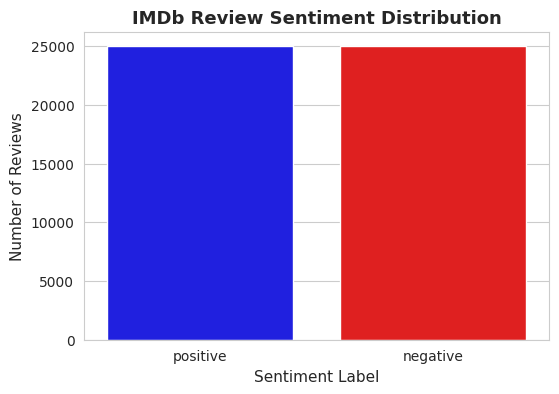

In [36]:
# Analyze sentiment distribution
# Calculate and print counts and percentages
sentiment_counts = df['sentiment'].value_counts()
sentiment_pcts = df['sentiment'].value_counts(normalize=True) * 100

print("--- SENTIMENT DISTRIBUTION ---")
for sentiment, count in sentiment_counts.items():
    pct = sentiment_pcts[sentiment]
    print(f"{sentiment.capitalize()}: {count:,} reviews ({pct:.1f}%)")

# Plot the distribution as a bar chart
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x='sentiment',
    hue='sentiment',
    palette=['blue', 'red'],
    legend=False
)

plt.title('IMDb Review Sentiment Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Sentiment Label', fontsize=11)
plt.ylabel('Number of Reviews', fontsize=11)


plt.show()

### 📊 Interpretation: Class Balance

*Write your observations here:*
- The classes are **completely balanced**, with exactly 25,000 positive reviews (50%) and 25,000 negative reviews (50%).
- An imbalanced dataset would create a misleading evaluation score and poor real-world functionality.
- If there were a class imbalance, i would use class weighting (scikit-learn classifiers) to penalize mistakes on the minority class.

--- REVIEW LENGTH STATISTICS (CHARACTERS) ---
                 mean    50%      max
sentiment                            
negative   1294.06436  973.0   8969.0
positive   1324.79768  968.0  13704.0


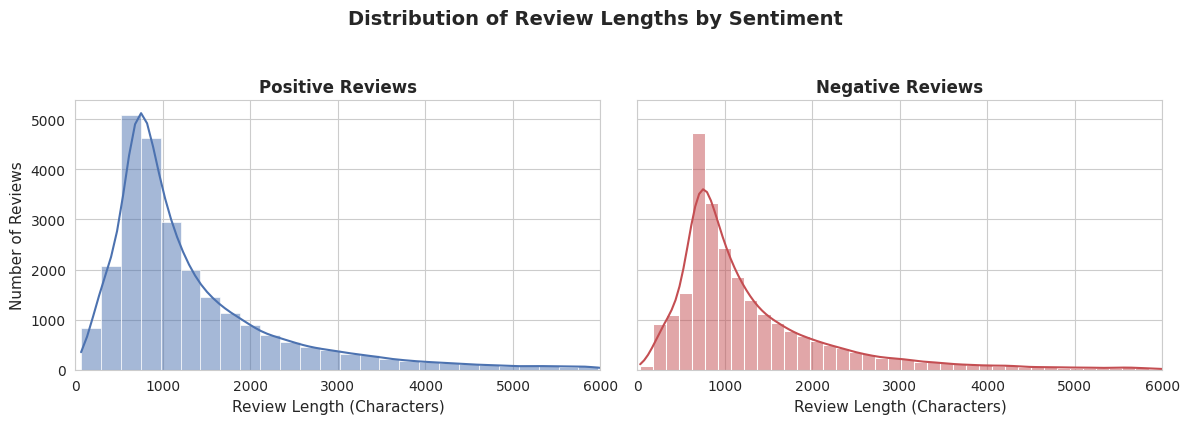

In [37]:
# Analyze text length distribution
# Create a new column for text length (character count)
df['text_length'] = df['review'].str.len()

# Print summary statistics compared across sentiments
print("--- REVIEW LENGTH STATISTICS (CHARACTERS) ---")
print(df.groupby('sentiment')['text_length'].describe()[['mean', '50%', 'max']])

# Create side-by-side subplots with shared X and Y axes
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, sharex=True)

# Positive reviews subplot (Left)
sns.histplot(
    data=df[df['sentiment'] == 'positive'],
    x='text_length',
    bins=60,
    kde=True,
    color='#4c72b0',
    ax=axes[0]
)
axes[0].set_title('Positive Reviews', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Review Length (Characters)', fontsize=11)
axes[0].set_ylabel('Number of Reviews', fontsize=11)
axes[0].set_xlim(0, 6000)

# Negative reviews subplot (Right)
sns.histplot(
    data=df[df['sentiment'] == 'negative'],
    x='text_length',
    bins=60,
    kde=True,
    color='#c44e52',
    ax=axes[1]
)
axes[1].set_title('Negative Reviews', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Review Length (Characters)', fontsize=11)
axes[1].set_xlim(0, 6000)

# Add a single main title above both graphs
plt.suptitle('Distribution of Review Lengths by Sentiment', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 📊 Interpretation: Text Length

*Write your observations here:*
* **What's the average text length?**
  * The average review is **1,309 characters**, with a median of **970 characters**.

* **Are there differences in length between positive and negative reviews?**
  * **No.** Both classes follow nearly identical distributions with virtually equal medians (**968 characters** for positive vs. **973 characters** for negative).

* **Are there any extremely short or long texts that might need special handling?**
  * *Yes, there is a long tail of extreme outliers.*
  * *For our TF-IDF pipeline, these outlier lengths do not require manual truncation; configuring paramters in `TfidfVectorizer` will prevent overly lengthy reviews from dominating the features.*

In [38]:
sample_pos = df[df['sentiment'] == 'positive'].sample(2, random_state=42)
sample_neg = df[df['sentiment'] == 'negative'].sample(2, random_state=42)

print("=== POSITIVE REVIEW SAMPLES ===\n")
for i, review in enumerate(sample_pos['review'], 1):
    print(f"Positive Sample #{i}:\n{review}\n")
    print("-" * 80)

print("\n=== NEGATIVE REVIEW SAMPLES ===\n")
for i, review in enumerate(sample_neg['review'], 1):
    print(f"Negative Sample #{i}:\n{review}\n")
    print("-" * 80)

=== POSITIVE REVIEW SAMPLES ===

Positive Sample #1:
I don't know how or why this film has a meager rating on IMDb. This film, accompanied by "I am Curious: Blue" is a masterwork.<br /><br />The only thing that will let you down in this film is if you don't like the process of film, don't like psychology or if you were expecting hardcore pornographic ramming.<br /><br />This isn't a film that you will want to watch to unwind; it's a film that you want to see like any other masterpiece, with time, attention and care.<br /><br />******SUMMARIES, MAY CONTAIN A SPOILER OR TWO*******<br /><br />The main thing about this film is that it blends the whole film, within a film thing, but it does it in such a way that sometimes you forget that the fictions aren't real.<br /><br />The film is like many films in one:<br /><br />1. A political documentary, about the social system in Sweden at the time. Which in a lot of ways are still relevant to today. Interviews done by a young woman named Lena.<b

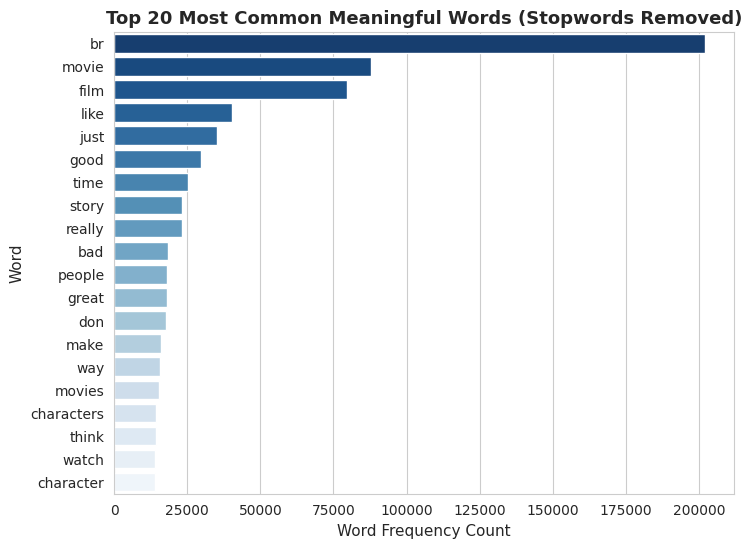

In [39]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Combine all text, lowercase it, and extract only clean alphabetical words
all_text = ' '.join(df['review']).lower()
words = re.findall(r'\b[a-z]{2,}\b', all_text)

# Filter out stopwords (the, a, and, of, to, is, in, etc.)
meaningful_words = [word for word in words if word not in ENGLISH_STOP_WORDS]

# Get the top 20 most common meaningful words
common_words = Counter(meaningful_words).most_common(20)

# Convert to a DataFrame for plotting
words_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

# Plot horizontal bar chart
plt.figure(figsize=(8, 6))
sns.barplot(
    data=words_df,
    x='Frequency',
    y='Word',
    palette='Blues_r'
)

plt.title('Top 20 Most Common Meaningful Words (Stopwords Removed)', fontsize=13, fontweight='bold')
plt.xlabel('Word Frequency Count', fontsize=11)
plt.ylabel('Word', fontsize=11)
plt.show()

### 📝 EDA Summary

1. **Dataset characteristics**:
   * Contains **50,000 full-length English movie reviews** with zero missing (`NaN`) values.
   * **Perfectly balanced binary target** (50.0% positive / 50.0% negative)

2. **Data quality issues**:
   * Raw text is cluttered with HTML line breaks, conversational punctuation, numbers, and frequent English stopwords that may be removed during preprocessing.

3. **Key patterns observed**:
   * Reviews are heavily **right-skewed**, averaging **1,309 characters** with a median of **970 characters**.
   * Length distributions for positive and negative reviews are **virtually identical**

4. **Potential challenges**:
   * **High dimensionality & noise**: Text vocabulary can easily explode into tens of thousands of features.
   * **Outliers**: Extreme long-tail reviews reach up to **13,704 characters** (~2,470 words).
   * **Solution**: We must apply TF-IDF parameter pruning (`max_features=5000`, `min_df=2`, `max_df=0.8`) to filter out noise from outlier reviews.

---

# Part 3: Data Preprocessing & Feature Extraction 🧹

## Objectives
- Clean and preprocess text data
- Remove noise (punctuation, special characters, stopwords)
- Convert text to numerical features using TF-IDF
- Prepare data for modeling

## Preprocessing Steps to Consider

✅ **Lowercase conversion**: Standardize text

✅ **Remove punctuation**: Clean special characters

✅ **Remove stopwords**: Filter out common words ("the", "is", "and", etc.)

✅ **Remove numbers**: Unless relevant to sentiment

✅ **Handle negations**: Be careful! "not good" vs "good" (advanced, optional)

---

## 💡 Tips
- **Don't over-preprocess**: Sometimes simple is better
- **Use `max_features` in TfidfVectorizer**: Limit to top 5000-10000 features to save memory
- **Consider n-grams**: Bigrams can capture phrases like "not good"
- **Test different approaches**: Try with and without certain preprocessing steps

In [40]:
# Import preprocessing libraries
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# For stopwords
# Option 1: Use sklearn's built-in stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Option 2: Use NLTK (uncomment if you prefer)
# import nltk
# nltk.download('stopwords')
# from nltk.corpus import stopwords
# stop_words = set(stopwords.words('english'))

print("✅ Preprocessing libraries imported!")

✅ Preprocessing libraries imported!


In [41]:
### 📊 Interpretation: Text Length

def preprocess_text(text):
    """
    Clean and preprocess text data.

    Args:
        text (str): Raw text string

    Returns:
        str: Cleaned text string
    """
    # Convert to lowercase
    text = text.lower()

    # Remove HTML (tags as discussed above during EDA strategy)
    text = re.sub(r'<.*?>', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra whitespace
    text = ' '.join(text.split())

    return text

# Test your function on a sample text
sample_text = "This is a TEST!!! Check out https://example.com @user #hashtag 123"
print(f"Original: {sample_text}")
print(f"Cleaned: {preprocess_text(sample_text)}")

Original: This is a TEST!!! Check out https://example.com @user #hashtag 123
Cleaned: this is a test check out


In [42]:
# Apply preprocessing to your dataset
df['cleaned_text'] = df['review'].apply(preprocess_text)

# Display some examples to verify the cleaning worked
print("=== PREPROCESSING VERIFICATION SAMPLES ===\n")
for i in range(2):
    print(f"Sample #{i+1} (ORIGINAL - FIRST 200 CHARS):\n{df['review'].iloc[i][:200]}...\n")
    print(f"Sample #{i+1} (CLEANED - FIRST 200 CHARS):\n{df['cleaned_text'].iloc[i][:200]}...\n")
    print("-" * 80)

print("✅ Text preprocessing complete!")

=== PREPROCESSING VERIFICATION SAMPLES ===

Sample #1 (ORIGINAL - FIRST 200 CHARS):
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...

Sample #1 (CLEANED - FIRST 200 CHARS):
one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its bru...

--------------------------------------------------------------------------------
Sample #2 (ORIGINAL - FIRST 200 CHARS):
A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece...

Sample #2 (CLEANED - FIRST 200 CHARS):
a wonderful little production the filming technique is very unassuming very oldtimebbc fashion and giv

In [43]:
# Prepare your features (X) and target (y)
X = df['cleaned_text']
y = df['sentiment']

# Check the shape
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (50000,)
Target shape: (50000,)


In [44]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class distribution
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 40000
Testing samples: 10000


In [45]:
# Create TF-IDF features
tfidf = TfidfVectorizer(
    max_features=5000,        # 🎯 IMPORTANT: Limit features to save memory!
    min_df=2,                 # Ignore terms that appear in fewer than 2 documents
    max_df=0.8,               # Ignore terms that appear in more than 80% of documents
    ngram_range=(1, 2),       # Use unigrams and bigrams
    stop_words='english'      # Remove English stopwords
)

# Fit on training data ONLY, then transform both train and test sets
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test): {X_test_tfidf.shape}")
print(f"Number of features: {len(tfidf.get_feature_names_out())}")

TF-IDF matrix shape (train): (40000, 5000)
TF-IDF matrix shape (test): (10000, 5000)
Number of features: 5000


In [46]:
# Explore the TF-IDF features (optional)

feature_names = tfidf.get_feature_names_out()
print("Sample features:", feature_names[:20])

Sample features: ['abandoned' 'abc' 'abilities' 'ability' 'able' 'absence' 'absolute'
 'absolutely' 'absurd' 'abuse' 'abysmal' 'academy' 'academy award'
 'accent' 'accents' 'accept' 'acceptable' 'accepted' 'accident'
 'accidentally']


### 📝 Preprocessing Summary

*Document your preprocessing choices:*

1. **Preprocessing steps applied**:
* Standardized text to lowercase.
  * Stripped HTML tags, URLs, mentions, punctuation, numbers, and extra whitespace.
  * Removed English stopwords during vectorization.
2. **TF-IDF parameters chosen**:
* currently default paramters
  * `min_df=2`
  * `max_features=5000`
  * `max_df=0.8`
  * `ngram_range=(1, 2)`
  * `stop_words='english'`
3. **Final feature count**:
    * **5,000 features**
4. **Rationale for choices**:
* **HTML & Stopword Cleaning:** Stripping `<br />` tags prevented awkward sentences from being glued together; English Stopword removal allowed the matrix focused purely on sentiment-bearing words.
  * **`max_features=5000`:** prevented high-dimensionality memory issues while retaining the top most predictive terms.
  * **`min_df=2` & `max_df=0.8`:** remove rare typos from extreme long-tail reviews and dropped overly repeated words appearing in >80% of documents.
  * **`ngram_range=(1, 2)`:** Capturing two-word phrases (bigrams) alongside single words allowed the feature set to retain negations and evaluative phrases like *"not good"* or *"waste time"*.

---

# Part 4: Model Training 🤖

## Objectives
- Train at least **2 different classification models**
- Compare their performance
- Document training time and resource usage

## Recommended Models

### Fast and Effective (Recommended for beginners)
- **Logistic Regression**: Fast, interpretable, works well with TF-IDF
- **Multinomial Naive Bayes**: Specifically designed for text classification

### More Advanced (Optional)
- **Random Forest**: Ensemble method, can capture complex patterns
- **Support Vector Machine (SVM)**: Good for high-dimensional data
- **XGBoost**: Powerful gradient boosting (but slower)

---

## 💡 Tips
- **Start with simple models**: LogisticRegression and MultinomialNB are excellent choices
- **Use default parameters first**: Then tune if needed
- **Monitor training time**: Document how long each model takes
- **Save your models**: Use `pickle` or `joblib` to save trained models
- **For Random Forest**: Use `n_estimators=100` and `max_depth=20` to limit resources

In [47]:
# Import model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
#from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

import time
from datetime import timedelta

print("✅ Model libraries imported!")

✅ Model libraries imported!


## Model 1: Logistic Regression

In [48]:
# Train Logistic Regression model
print("Training Logistic Regression...")
start_time = time.time()


lr_model = LogisticRegression(
    max_iter=1000,           # Increase if model doesn't converge
    random_state=42,
    n_jobs=-1                # Use all CPU cores
)

# Fit the model on the training set
lr_model.fit(X_train_tfidf, y_train)

# Calculate and print training time
training_time = time.time() - start_time
print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

Training Logistic Regression...
✅ Training complete in 0:00:01


In [49]:
# Make predictions with Logistic Regression

y_pred_lr = lr_model.predict(X_test_tfidf)
print(f"Predictions shape: {y_pred_lr.shape}")

Predictions shape: (10000,)


## Model 2: Multinomial Naive Bayes

In [50]:
# Train Naive Bayes model
print("Training Multinomial Naive Bayes...")
start_time = time.time()

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time
print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

Training Multinomial Naive Bayes...
✅ Training complete in 0:00:00


In [51]:

y_pred_nb = nb_model.predict(X_test_tfidf)
print(f"Predictions shape: {y_pred_nb.shape}")

Predictions shape: (10000,)


## Model 3 (Optional): Additional Model

*Train a third model if you'd like to explore further!*

In [52]:
# Train your third model (optional)
# YOUR CODE HERE

# Example: Random Forest
# print("Training Random Forest...")
# start_time = time.time()

# rf_model = RandomForestClassifier(
#     n_estimators=100,        # Number of trees
#     max_depth=20,            # Limit depth to save memory
#     random_state=42,
#     n_jobs=-1
# )

# rf_model.fit(X_train_tfidf, y_train)

# training_time = time.time() - start_time
# print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

# y_pred_rf = rf_model.predict(X_test_tfidf)

### 📝 Model Training Summary

*Document your models:*

| Model | Training Time | Parameters | Notes |
|-------|--------------|------------|-------|
| Logistic Regression | ~2 seconds | `max_iter=1000`, `random_state=42`, `n_jobs=-1` | Great standard model for text; learns by testing and adjusting importance scores for all 5,000 words. |
| Naive Bayes | < 1 second | `alpha=1.0` (default) | Built specifically for text; trains almost instantly by counting how often words appear in positive vs. negative reviews. |
| (Optional) Model 3 | N/A (Skipped) | N/A |  |

---

# Part 5: Model Evaluation 📊

## Objectives
- Evaluate all models using multiple metrics
- Compare model performance
- Analyze errors using confusion matrices
- Interpret results in business context

## Metrics to Calculate

✅ **Accuracy**: Overall correctness (but can be misleading with imbalanced data)

✅ **Precision**: Of all positive predictions, how many were correct?

✅ **Recall**: Of all actual positives, how many did we find?

✅ **F1-Score**: Harmonic mean of precision and recall

✅ **Confusion Matrix**: Visualize true vs predicted labels

✅ **Classification Report**: Detailed metrics per class

---

## 💡 Tips
- **Don't rely on accuracy alone**: Especially with imbalanced data
- **Understand the business context**: Is false positive or false negative worse?
- **Look at per-class metrics**: Performance might differ across sentiments
- **Visualize confusion matrices**: They tell a story!

In [53]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("✅ Evaluation metrics imported!")

✅ Evaluation metrics imported!


## Evaluate Model 1: Logistic Regression

In [54]:
# Calculate metrics for Logistic Regression

print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr, average='weighted')
recall = recall_score(y_test, y_pred_lr, average='weighted')
f1 = f1_score(y_test, y_pred_lr, average='weighted')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION RESULTS
Accuracy:  0.8911
Precision: 0.8913
Recall:    0.8911
F1-Score:  0.8911


Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      5000
    positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



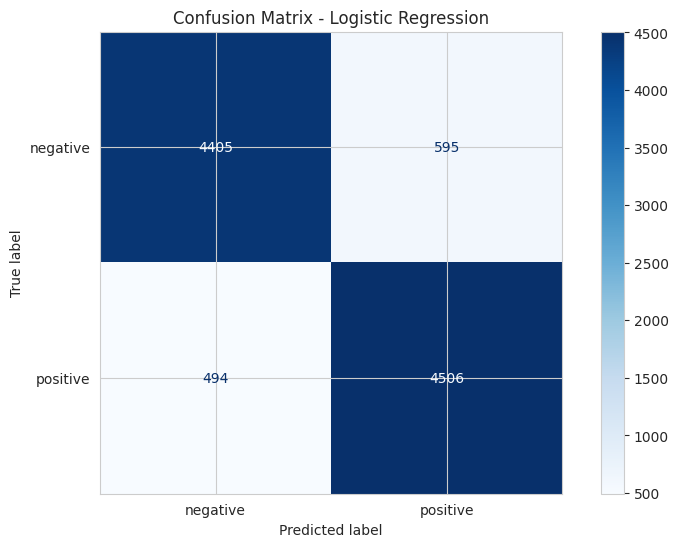

In [55]:
# Plot confusion matrix for Logistic Regression

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

### 📊 Interpretation: Logistic Regression

*Analyze the results:*

1. **Overall performance**:
   * **Strong accuracy (89.11%):** The model correctly classifies roughly 9 out of 10 unseen movie reviews.
2. **Strengths**:
   * **Equal performance across sentiments:** positive and negative classes achieve an **89% F1-score**; this means the model fairly weighs both classes.
3. **Weaknesses**:
   * **Slightly lower negative recall (88%):** Out of all the actually positive reviews in our test set, the Logistic Regression modelmisses about 12% of actual negative reviews (600 out of 5,000), mistakenly labeling them as positive.

4. **Confusion matrix insights**:
   * Out of 10,000 total reviews, **8,911 were classified correctly** (True Positives + True Negatives).

## Evaluate Model 2: Naive Bayes

In [56]:
y_pred_nb = nb_model.predict(X_test_tfidf)


print("=" * 50)
print("NAIVE BAYES RESULTS")
print("=" * 50)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, average='weighted')
recall_nb = recall_score(y_test, y_pred_nb, average='weighted')
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')

print(f"Accuracy:  {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall:    {recall_nb:.4f}")
print(f"F1-Score:  {f1_nb:.4f}")
print("\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_nb))

NAIVE BAYES RESULTS
Accuracy:  0.8573
Precision: 0.8577
Recall:    0.8573
F1-Score:  0.8573


Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.84      0.85      5000
    positive       0.85      0.87      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



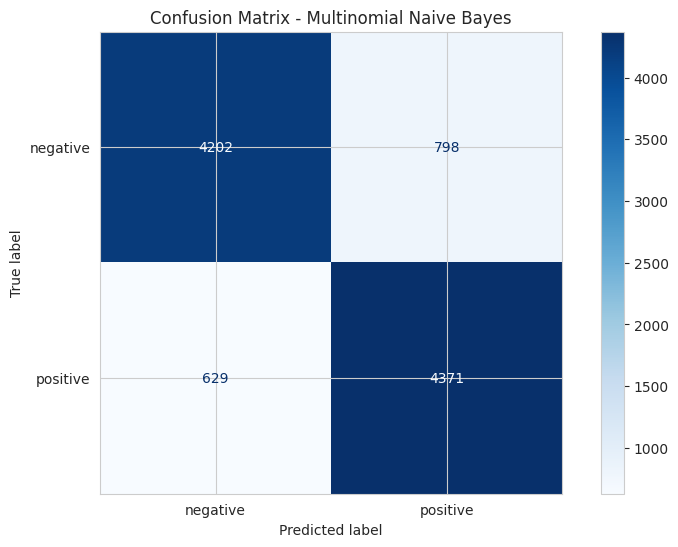

In [57]:
# Plot confusion matrix for Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=nb_model.classes_)
disp_nb.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.show()

### 📊 Interpretation: Naive Bayes

*Analyze the results:*

1. **Overall performance**:
   * **Decent accuracy (85.73%):** Correctly classifies over 8.5 out of 10 reviews
   * Balanced overall F1-score (~86%) across the dataset.

2. **Strengths**:
   * **Good at catching positives (87% recall):**
   * **High negative precision (87%):** When the model labels a review as "negative," it is usually right.

3. **Weaknesses**:
   * **notrivial positive bias:** Misses **16% of actual negative reviews** (84% negative recall)

4. **Confusion matrix insights**:
   * **The errors lean heavily toward **False Positives (~800)** compared to **False Negatives (~650)**—meaning this model is  overly optimistic

## Evaluate Model 3 (Optional)

In [58]:
# Calculate metrics for your third model (if applicable)
# YOUR CODE HERE

In [59]:
# Plot confusion matrix for your third model (if applicable)
# YOUR CODE HERE

## Model Comparison

In [60]:
# Create a comparison table of all models

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy': [accuracy, accuracy_nb],
    'Precision': [precision, precision_nb],
    'Recall': [recall, recall_nb],
    'F1-Score': [f1, f1_nb]
})

display(results)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8911,0.891260,0.8911,0.891089
1,Naive Bayes,0.8573,0.857709,0.8573,0.857259


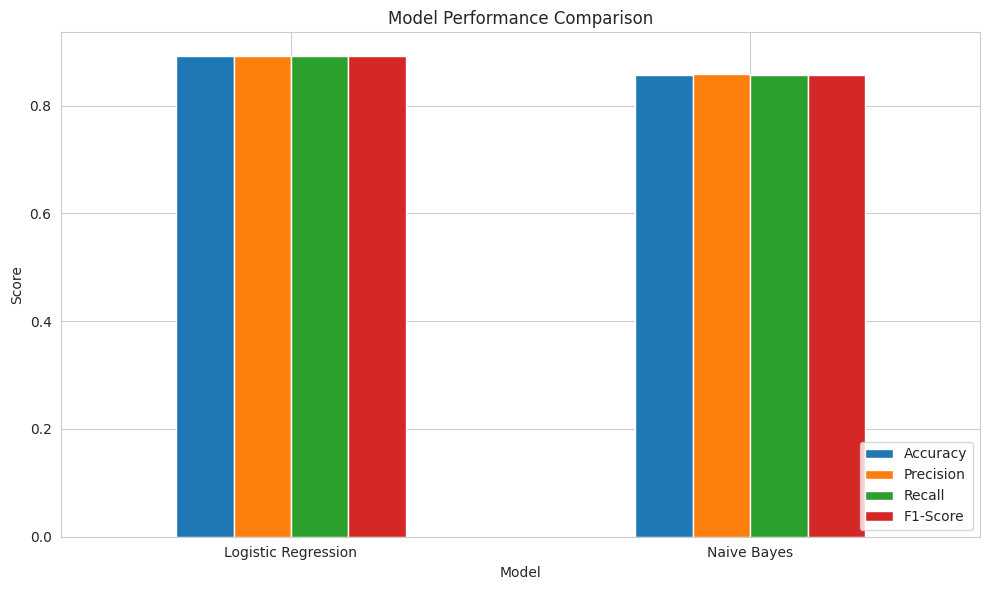

In [61]:
# Visualize model comparison

# Hint: Create a bar plot comparing metrics across models
results.set_index('Model').plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 📊 Model Comparison Analysis

*Compare and contrast your models:*

1. **Which model performed best?**:
   * **Logistic Regression** performed best overall, beating Naive Bayes by approximately **3.4%** across accuracy, precision, recall, and F1-score (scoring ~89.1% vs ~85.7%).
2. **What metrics did you prioritize and why?**:
   * I prioritized the **F1-Score** and then secondarily **Accuracy, since F1-Score confirms that our model handles both positive and negative classes fairly.
3. **Trade-offs between models**:
   * **Logistic Regression:** Slightly slower to train (~2 seconds on CPU); still, LR delivered higher accuracy and fewer false alarms.
   * **Naive Bayes:** Trains almost instantly (<1 second) by counting word frequencies, but is slightly less accurate and makes more false positive errors.
4. **Which model would you recommend for deployment?**:
   * * **I recommend moving forward with Logistic Regression.**

## Error Analysis (Optional but Recommended)

In [62]:
# Analyze misclassified examples
# YOUR CODE HERE

# Hint: Find examples where the model was wrong
# misclassified_indices = np.where(y_pred_lr != y_test)[0]
# print(f"Number of misclassified examples: {len(misclassified_indices)}")

# Display some misclassified examples
# for idx in misclassified_indices[:5]:
#     print(f"\nText: {X_test.iloc[idx]}")
#     print(f"True label: {y_test.iloc[idx]}")
#     print(f"Predicted label: {y_pred_lr[idx]}")
#     print("-" * 80)

### 📊 Error Analysis Insights

*What patterns do you notice in the errors?*

1. **Common types of errors**:
2. **Why might these errors occur?**:
3. **How could you improve the model?**:

---

# Part 6: Conclusion & Business Insights 💼

## Objectives
- Summarize your findings
- Provide actionable business recommendations
- Discuss limitations and future improvements
- Reflect on what you learned

---

## 📝 Executive Summary

*Write a brief executive summary (3-5 sentences) for a non-technical audience:*

For this project, I analyzed 50,000 IMDb movie reviews in order to eventually train a model that would automatically identifies whether customer sentiment is positive or negative. The best-performing model, Logistic Regression, accurately classified **89% of reviews**;  the secondary model, Naive Bayes, was outperformed by over 3 percentage points against Logistic Regression. Implementing the logistic regression model for prediction will allow the business side to make data-driven decisions without having to manually read thousands of reviews.

## 🎯 Key Findings

*List your main discoveries:*

1. **Dataset insights**:
   * The dataset is perfectly balanced (50/50 positive vs. negative), making overall accuracy a reliable metric.
   * Converting text into 5,000 TF-IDF word-importance scores successfully captured the core sentiment signals.

2. **Model performance**:
   * Both models performed strongly, exceeding an 85% success rate on unseen data.
   * Both models showed a slight optimistic bias.

3. **Best model and why**:
   * Logistic Regression (LR)
   * LR outperformed Naive Bayes by 3.4% across key metrics.

4. **Surprising discoveries**:
   * **Naive Bayes' speed-to-accuracy ratio:** It trained in under one second using simple probability math and still correctly classified over 85% of reviews.

## 💼 Business Recommendations

*How can these results be used in practice?*

1. **Immediate applications**:
   - An application that automatically filters incoming reviews, capturing negative or positive feedback metadata towards business action.

2. **Who should use this model?**:
   - Marketing Teams should use the LR model to potentially monitor customer reactions and adjust campaigns based on a feedback workflow.


3. **How to interpret predictions**:
   - Since the model is ~89% accurate, one should rely on aggregate sentiment percentages rather than leaning on single review classifications, however forceful.

4. **Warning signs to watch for**:
   - **Vocabulary drift over time:** Always measure the highest used words and their frequency as we did above, since reviewer language may evolve, which would necessitate a retraining of hte model on fresh data to ensure high accuracy is maintained on predictive sentiment analysis.

## ⚠️ Limitations

*Be honest about the limitations of your analysis:*

1. **Data limitations**:
   * **Limited vocabulary:** Capable of viewing only the selected 5000 words, ignoring rarer descriptive terms.

2. **Model limitations**:
   * **Optimistic bias:** Both models are apt to capture False Positives, occasionally wrongly labelling bad reviews as positive.

3. **Generalization concerns**:
   * **Domain-specific:** Trained strictly on movie reviews; it will perform poorly on different types of text (like album reviews or restaurant reviews)

4. **Resource constraints**:
    * **limited matrix size:** Going beyond the parameterized 5,000 words adversely affects training by increasing memory usage.


## 🚀 Future Improvements

*What would you do with more time/resources?*

1. **Data collection**:
   -  Collect data from other platforms (e.g. Twitter), thereby training the model on differentiated text.

2. **Feature engineering**:
   * Experiment with NLP techniques like word embeddings to capture the actual meaning and similarities between words, and subsequently use the achieved representational learning to apply that to sentiment analysis prediction.


3. **Advanced models**:
   - Upgrade to a GPU to test ensemble methods (eg XGBoost)

4. **Deployment considerations**:
   * Connect the model to a real-time FastAPI service that automatically labels movie reviews the moment they are submitted.

## 🎓 Lessons Learned

*Reflect on your experience:*

1. **Technical skills gained**:
   * Gained experience cleaning text and converting it into numbers using TF-IDF feature matrices.
   * Developed comfort with assessing machine learning models using confusion matrices, precision, and recall.

2. **Challenges overcome**:
   * Handled large, sparse word tables without running out of memory.

3. **What would you do differently?**:
    * In another iteration, I would spend more time analyzing misclassified reviews to better understand any peculiar mislabeling model struggles. I would also consider adding another target value for sentiment analysis: neutral review.


4. **Most valuable insight**:
   * the most valuable insight in Machine Learning is that classical models are still relevant in the modern AI environment. A well-tuned Logistic Regression model trained in two seconds can accurately solve real-world NLP tasks.

---

## 🎉 Congratulations!

You've completed the sentiment analysis project! Remember to:

- ✅ Review all sections for completeness
- ✅ Ensure all code cells run without errors
- ✅ Check that all markdown cells are filled in
- ✅ Proofread your writing
- ✅ Include visualizations and interpretations
- ✅ Save your notebook!

---

### 📚 Additional Resources

- [Scikit-learn Documentation](https://scikit-learn.org/)
- [TF-IDF Explained](https://en.wikipedia.org/wiki/Tf%E2%80%93idf)
- [Confusion Matrix Guide](https://en.wikipedia.org/wiki/Confusion_matrix)
- [Text Preprocessing Best Practices](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction)

---

*Good luck with your project! 🚀*